**Statistical analysis between 2 specific groups of interest**: This Jupyter notebook conducts targeted statistical analyses comparing heart rate variability (HRV) metrics between specific groups of clinical interest. It features several focused sub-analyses: comparing "Pre-mature" (younger) vs. "Mature/Older" patient cohorts, evaluating the extreme poles of aging by comparing the youngest group against the elderly, and isolating the "Midlife transition" phase by comparing consecutive middle-aged cohorts. In each sub-analysis, the code applies Mann-Whitney U tests followed by a manual Benjamini-Hochberg False Discovery Rate ($FDR$) correction to compare multiple linear and non-linear HRV parameters simultaneously. Finally, the notebook computes and plots gender-specific linear regression slopes across age groups to evaluate and compare the rate of autonomic and cardiac metric decline between males and females over the lifespan.

Files used: analysis_groups.csv,final_hrv_linear_results.csv,final_hrv_non_linear_results.csv

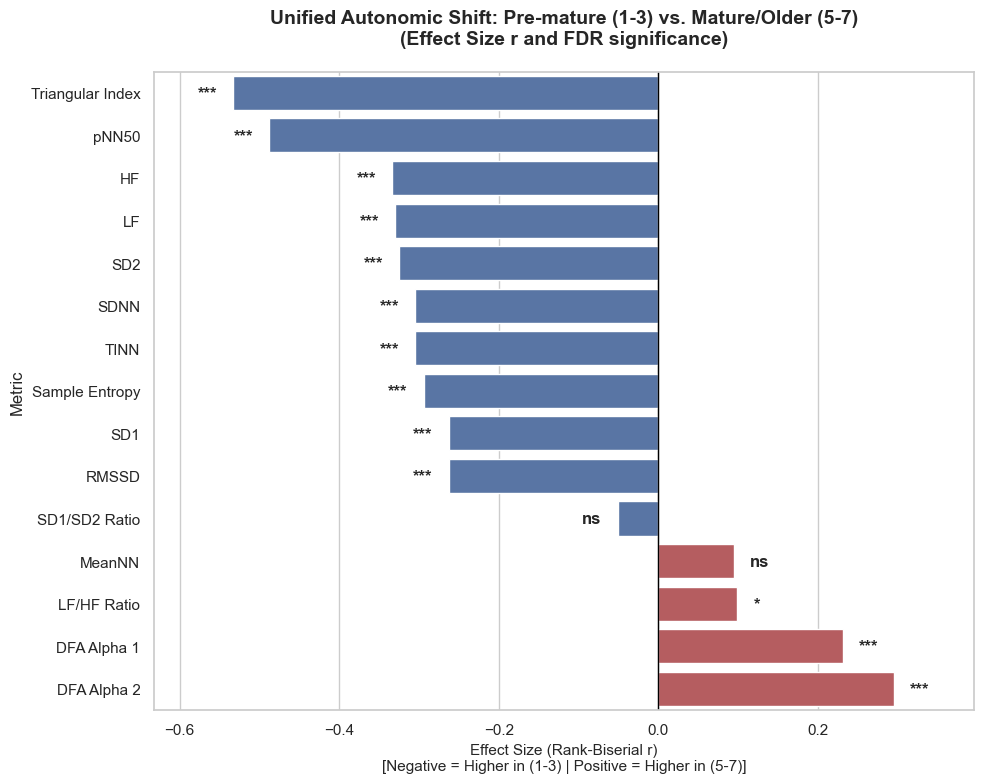

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


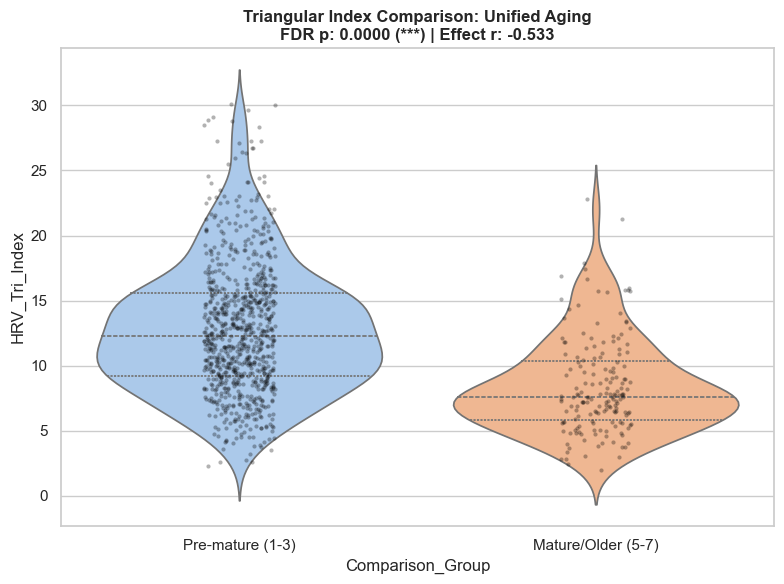

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


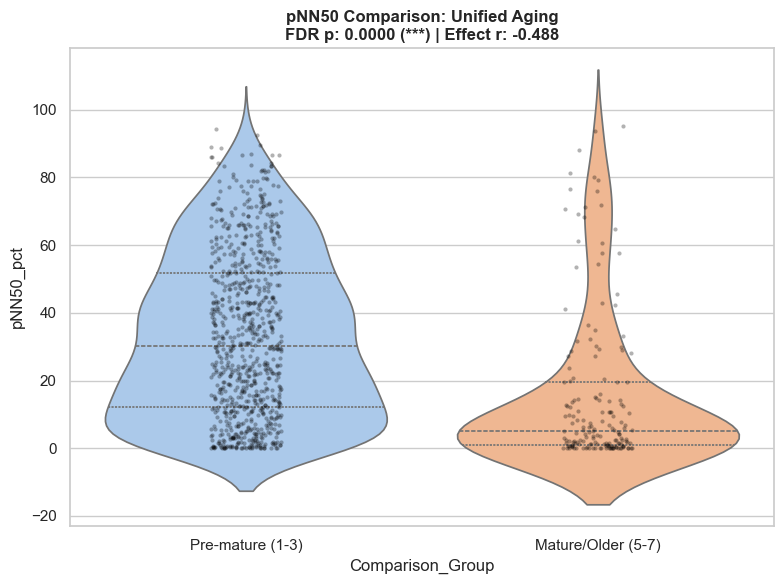

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


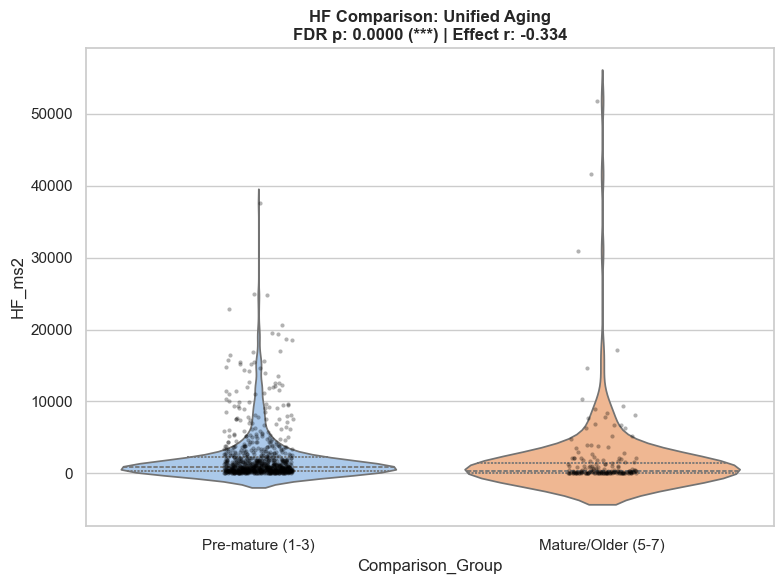

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


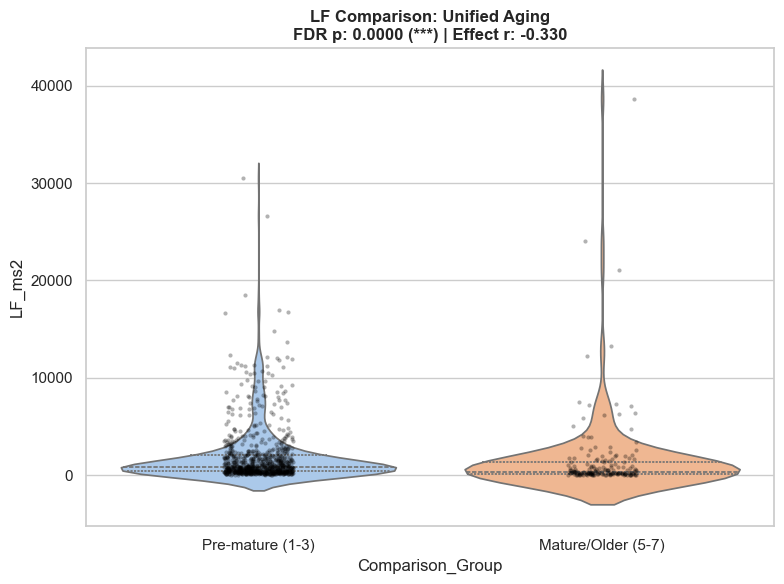

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


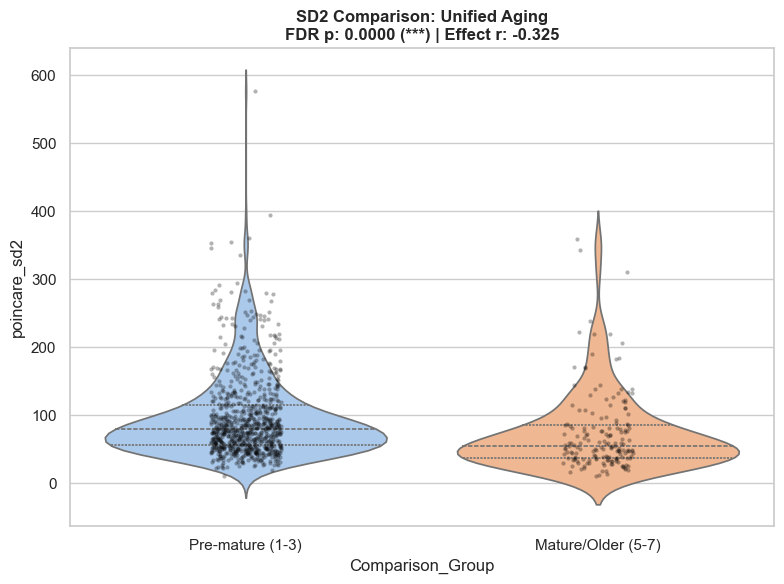

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


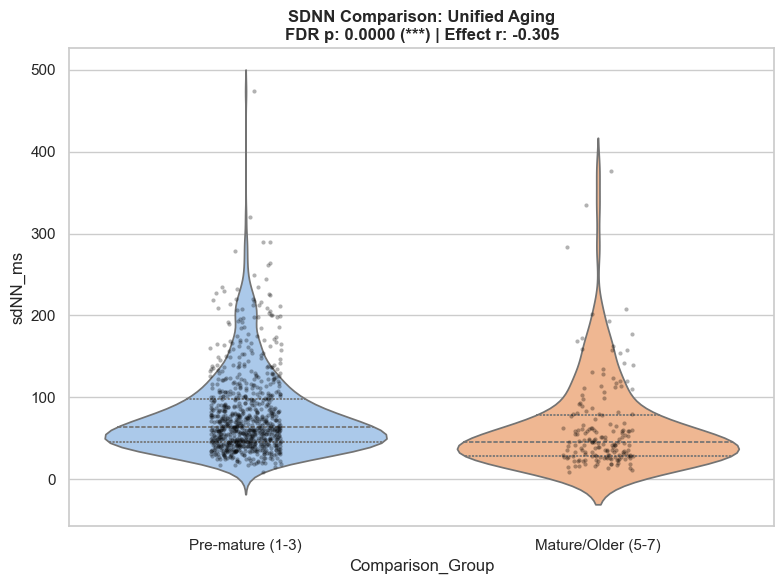

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


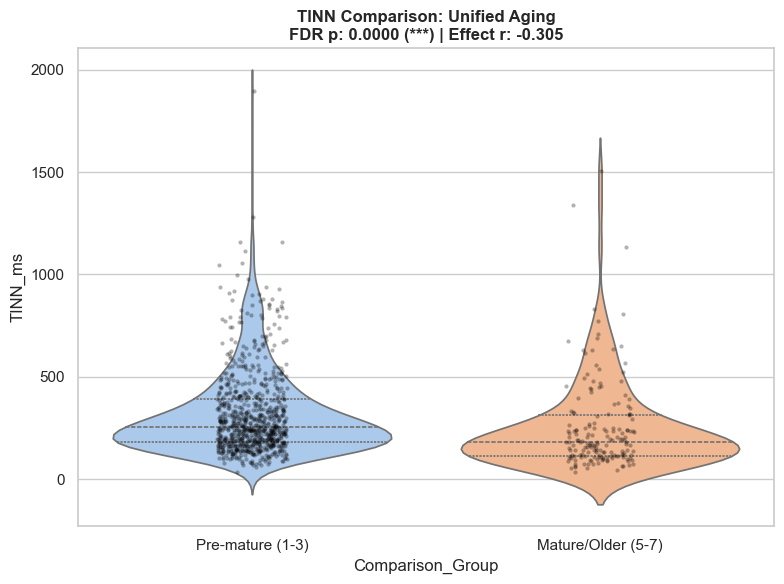

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


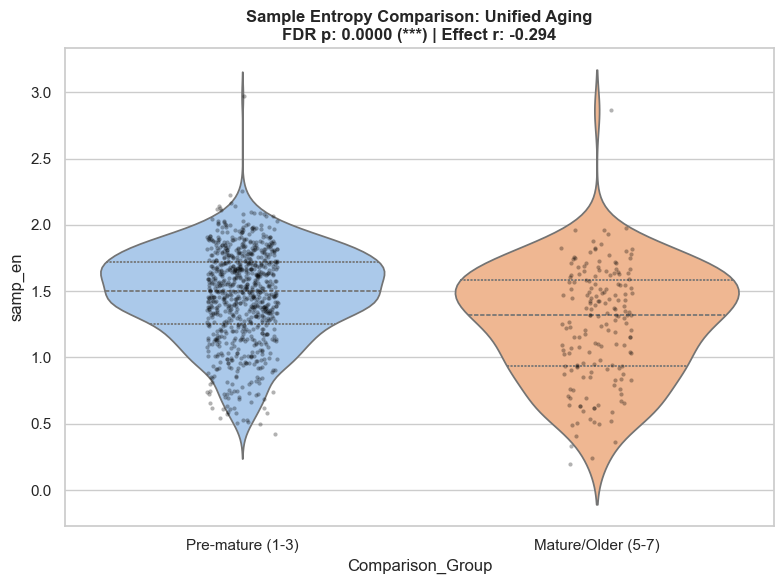

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


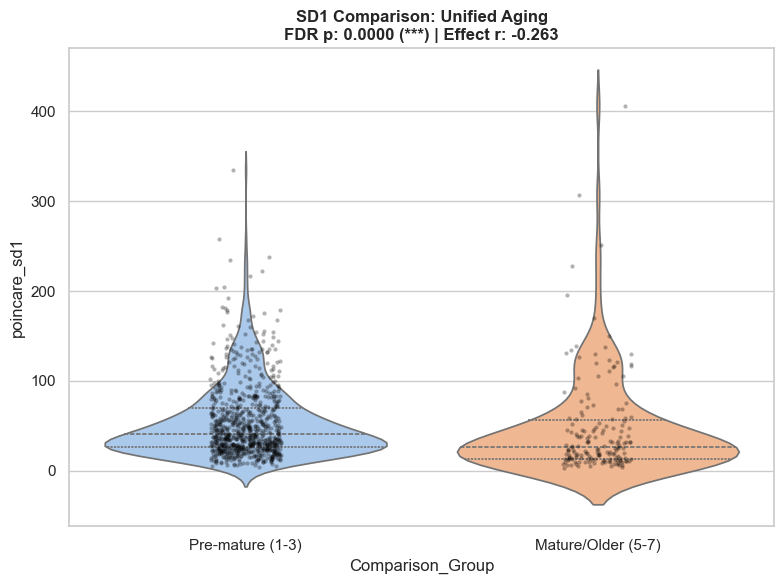

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


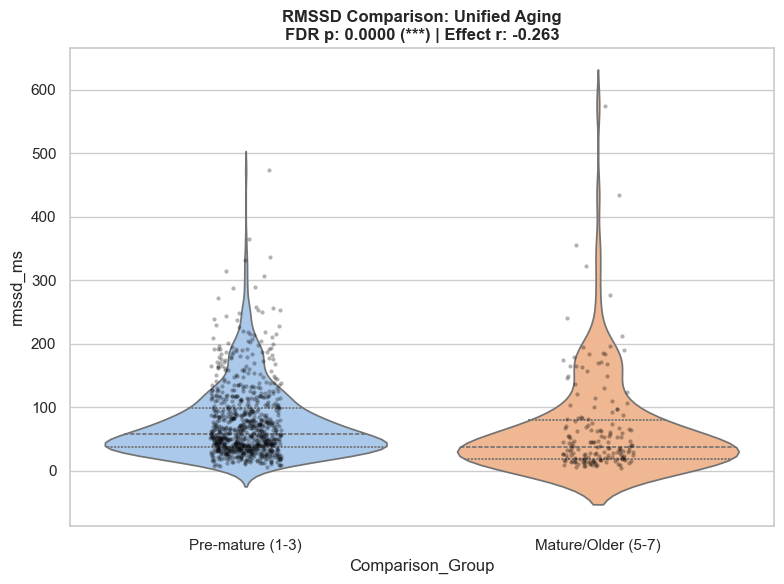

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


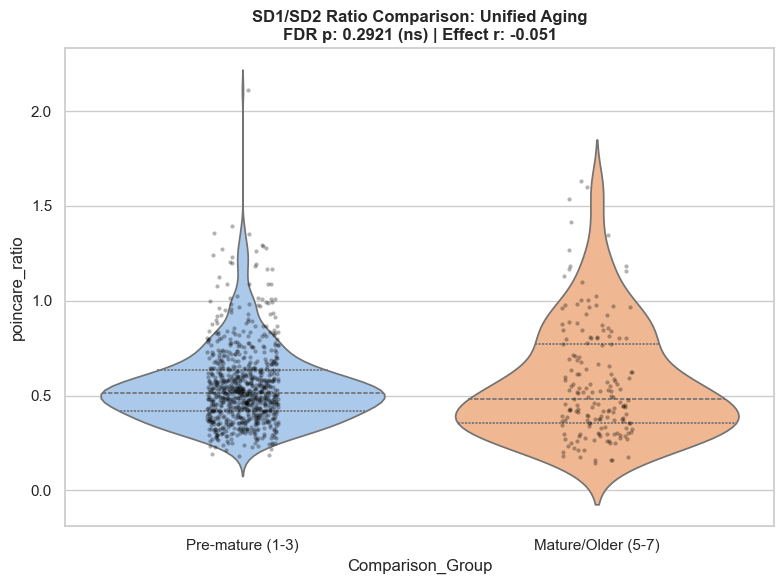

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


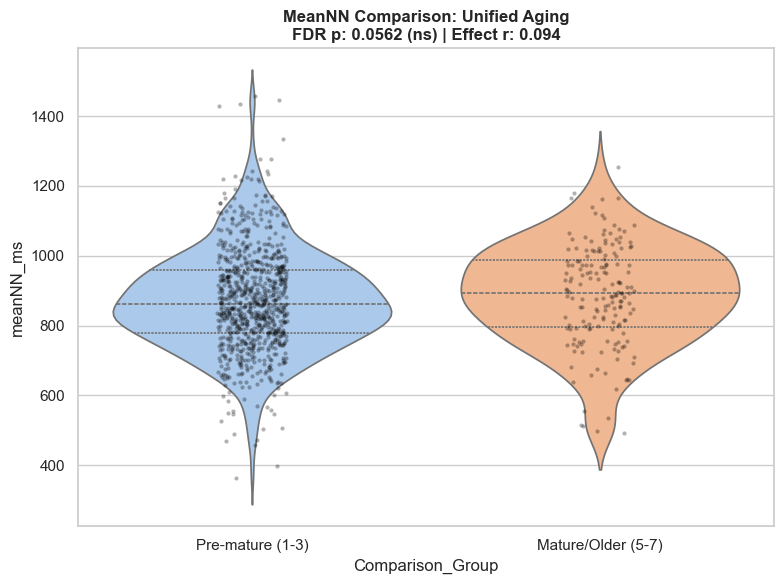

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


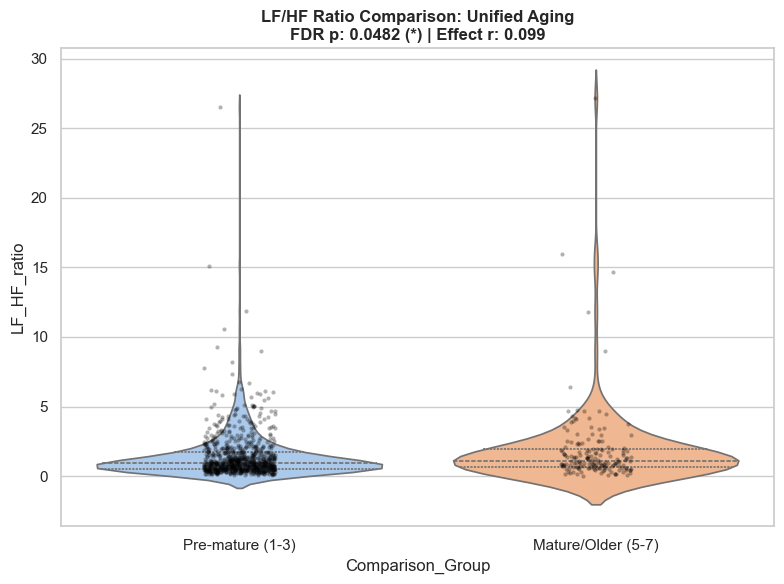

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


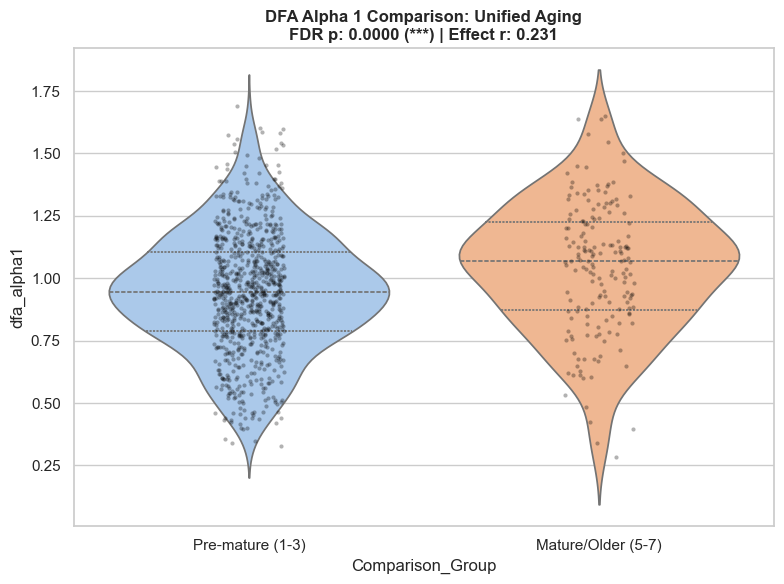

C:\Users\34673\AppData\Local\Temp\ipykernel_7104\1381176091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


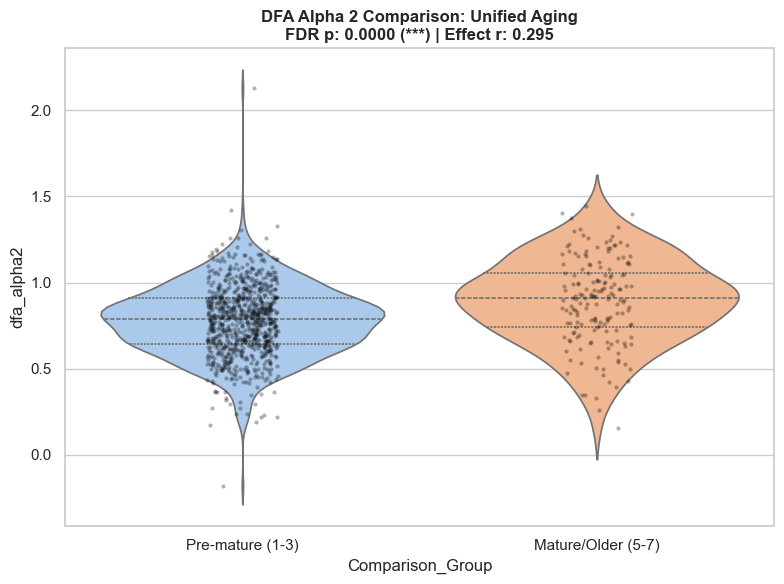

Full Unified Post-hoc Analysis and Plotting Complete.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manual FDR Correction Function
def fdrcorrection_manual(pvals, alpha=0.05):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = pvals.argsort()
    pvals_sorted = pvals[order]
    ecdffactor = np.arange(1, n + 1) / float(n)
    reject = pvals_sorted <= (ecdffactor * alpha)
    if reject.any():
        reject_max = reject.nonzero()[0].max()
        reject[:reject_max + 1] = True
    pvals_corrected_raw = pvals_sorted / ecdffactor
    pvals_corrected = np.minimum.accumulate(pvals_corrected_raw[::-1])[::-1]
    pvals_corrected[pvals_corrected > 1] = 1
    out_reject = np.empty_like(reject)
    out_reject[order] = reject
    out_pvals_corrected = np.empty_like(pvals_corrected)
    out_pvals_corrected[order] = pvals_corrected
    return out_reject, out_pvals_corrected

# 2. Load and Prepare Data
df_groups = pd.read_csv('analysis_groups.csv')
df_linear = pd.read_csv('final_hrv_linear_results.csv')
df_nonlinear = pd.read_csv('final_hrv_non_linear_results.csv')

# Sync IDs across files
for df in [df_groups, df_linear, df_nonlinear]:
    if 'Patient_ID' in df.columns:
        df.rename(columns={'Patient_ID': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.lstrip('0')

# Merge into master dataframe
df_merged = pd.merge(df_groups, df_linear, on='ID', how='inner')
df_merged = pd.merge(df_merged, df_nonlinear, on='ID', how='inner')

# 3. Create Unified Comparison Groups (G1+2+3 vs G5+6+7) 
def map_groups_modified(age_group):
    if age_group in [1, 2, 3]: return 'Pre-mature (1-3)'
    elif age_group in [5, 6, 7]: return 'Mature/Older (5-7)'
    return None

df_merged['Comparison_Group'] = df_merged['HRV_Age_Group'].apply(map_groups_modified)
df_analysis = df_merged.dropna(subset=['Comparison_Group'])

# 4. Define Metrics & Run Statistical Comparisons 
metrics_map = {
    'meanNN_ms': 'MeanNN', 'sdNN_ms': 'SDNN', 'rmssd_ms': 'RMSSD',
    'pNN50_pct': 'pNN50', 'LF_ms2': 'LF', 'HF_ms2': 'HF',
    'LF_HF_ratio': 'LF/HF Ratio', 'HRV_Tri_Index': 'Triangular Index',
    'TINN_ms': 'TINN', 'samp_en': 'Sample Entropy',
    'dfa_alpha1': 'DFA Alpha 1', 'dfa_alpha2': 'DFA Alpha 2',
    'poincare_sd1': 'SD1', 'poincare_sd2': 'SD2', 'poincare_ratio': 'SD1/SD2 Ratio'
}

results = []
g_a = df_analysis[df_analysis['Comparison_Group'] == 'Pre-mature (1-3)']
g_b = df_analysis[df_analysis['Comparison_Group'] == 'Mature/Older (5-7)']

for col, clean_name in metrics_map.items():
    if col in df_analysis.columns:
        y_data = g_a[col].dropna()
        o_data = g_b[col].dropna()
        if len(y_data) > 0 and len(o_data) > 0:
            u_stat, p_val = stats.mannwhitneyu(y_data, o_data, alternative='two-sided')
            r = 1 - (2 * u_stat / (len(y_data) * len(o_data)))
            results.append({'Metric': clean_name, 'p_value': p_val, 'r': r, 'Col': col})

# Apply FDR correction
df_stats = pd.DataFrame(results)
_, p_adj = fdrcorrection_manual(df_stats['p_value'].values)
df_stats['p_FDR'] = p_adj

# 5. VISUAL 1: Autonomic Shift Summary Map
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
df_stats = df_stats.sort_values('r', ascending=True)

colors = ['#4C72B0' if x < 0 else '#C44E52' for x in df_stats['r']]

ax = sns.barplot(
    data=df_stats, 
    x='r', 
    y='Metric', 
    hue='Metric', 
    palette=colors, 
    legend=False
)

# Add significance stars
for i, (p, r) in enumerate(zip(df_stats['p_FDR'], df_stats['r'])):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    offset = 0.02 if r >= 0 else -0.02
    ax.text(r + offset, i, stars, va='center', ha='left' if r >= 0 else 'right', fontweight='bold', fontsize=12)

plt.title('Unified Autonomic Shift: Pre-mature (1-3) vs. Mature/Older (5-7)\n(Effect Size r and FDR significance)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Effect Size (Rank-Biserial r)\n[Negative = Higher in (1-3) | Positive = Higher in (5-7)]', fontsize=11)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(df_stats['r'].min() - 0.1, df_stats['r'].max() + 0.1)
plt.tight_layout()
plt.show()

# 6. VISUAL 2: Individual Unified Violin Plots 
for _, row in df_stats.iterrows():
    m = row['Col']
    clean_name = row['Metric']
    fdr_p = row['p_FDR']
    r_val = row['r']

    plt.figure(figsize=(8, 6))
    sns.violinplot(
        data=df_analysis, 
        x='Comparison_Group', 
        y=m, 
        order=['Pre-mature (1-3)', 'Mature/Older (5-7)'], 
        inner='quartile', 
        palette="pastel"
    )
    sns.stripplot(
        data=df_analysis, 
        x='Comparison_Group', 
        y=m, 
        order=['Pre-mature (1-3)', 'Mature/Older (5-7)'], 
        color="black", alpha=0.3, jitter=True, size=3
    )

    stars = "***" if fdr_p < 0.001 else "**" if fdr_p < 0.01 else "*" if fdr_p < 0.05 else "ns"
    plt.title(f"{clean_name} Comparison: Unified Aging\nFDR p: {fdr_p:.4f} ({stars}) | Effect r: {r_val:.3f}", 
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Full Unified Post-hoc Analysis and Plotting Complete.")

Differences between young and elderly (extrme poles) - @article{voss2015short, title={Short-term heart rate variability—influence of gender and age in healthy subjects}, author={Voss, Andreas and Schroeder, Rico and Heitmann, Andreas and Peters, Annette and Perz, Siegfried}, journal={PloS one}, volume={10}, number={3}, pages={e0118308}, year={2015}, publisher={Public Library of Science San Francisco, CA USA} }

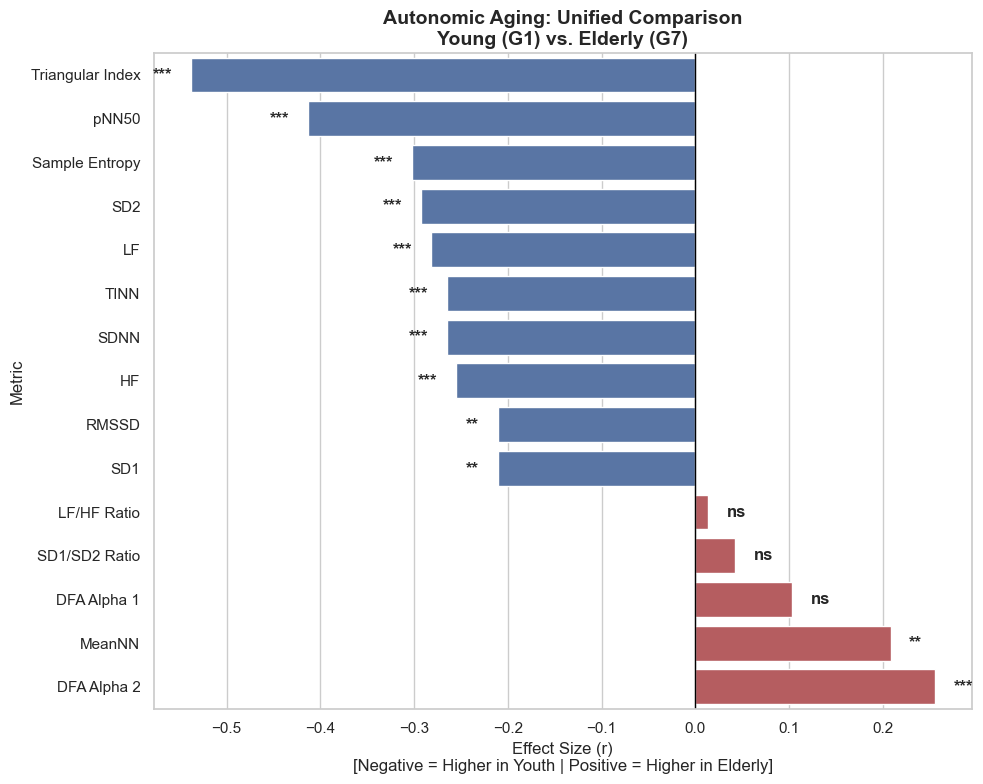

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


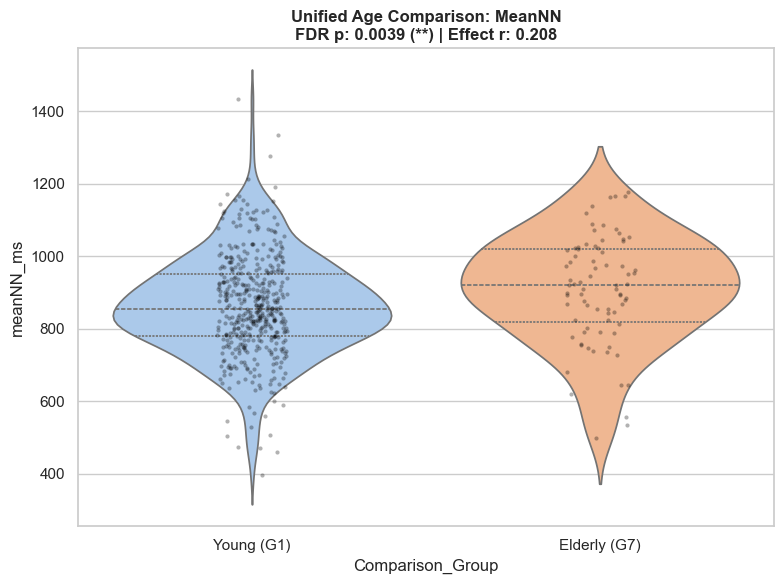

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


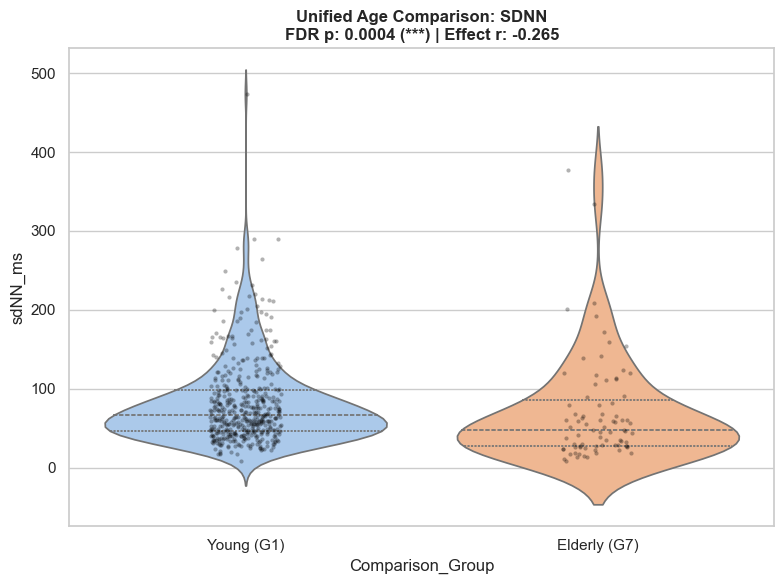

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


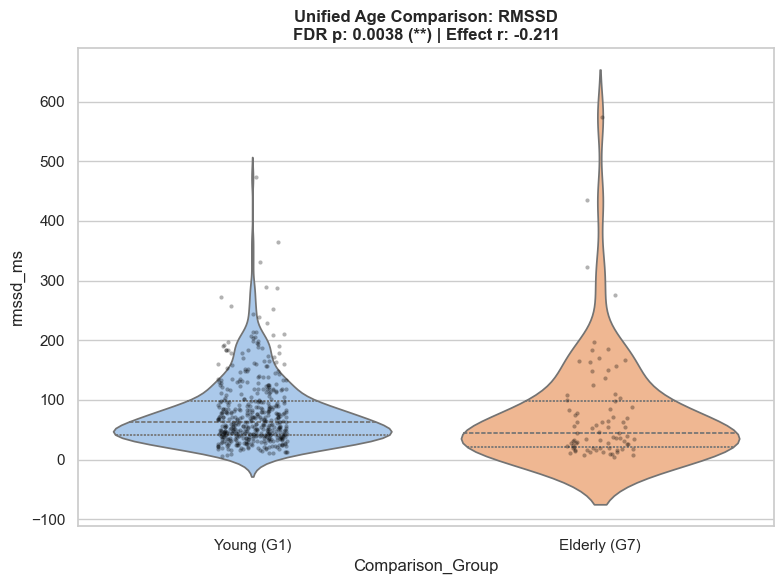

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


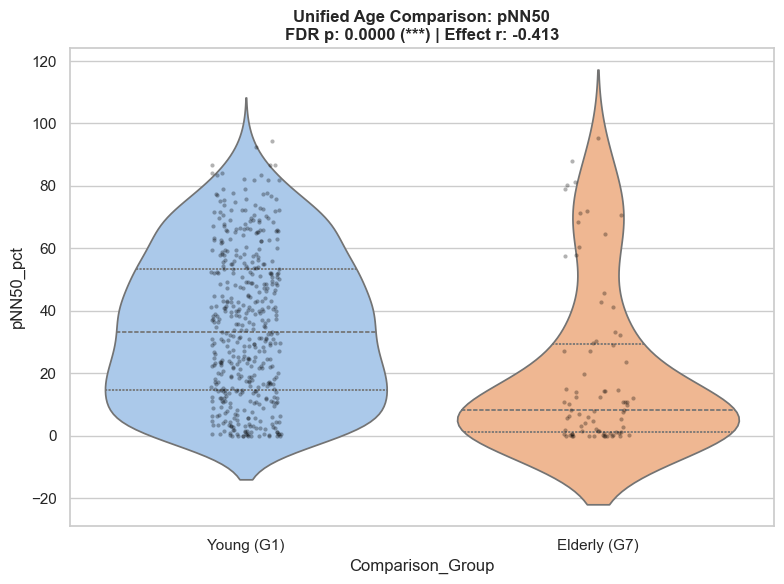

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


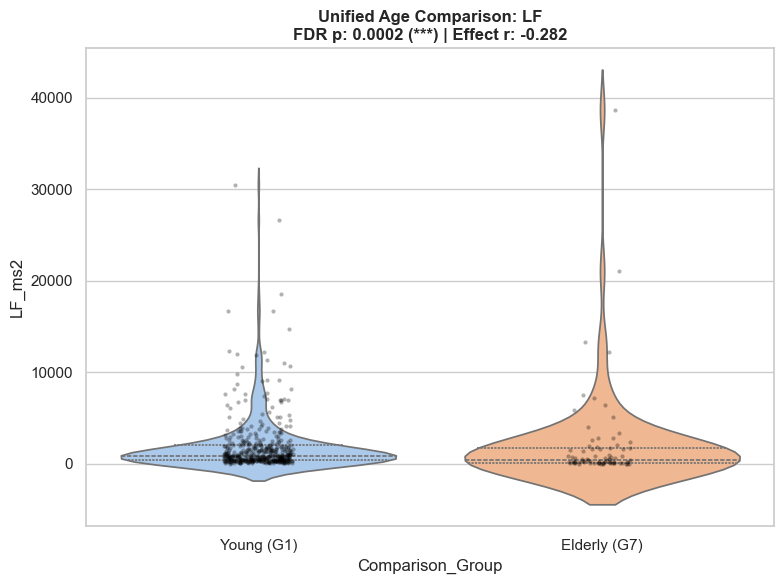

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


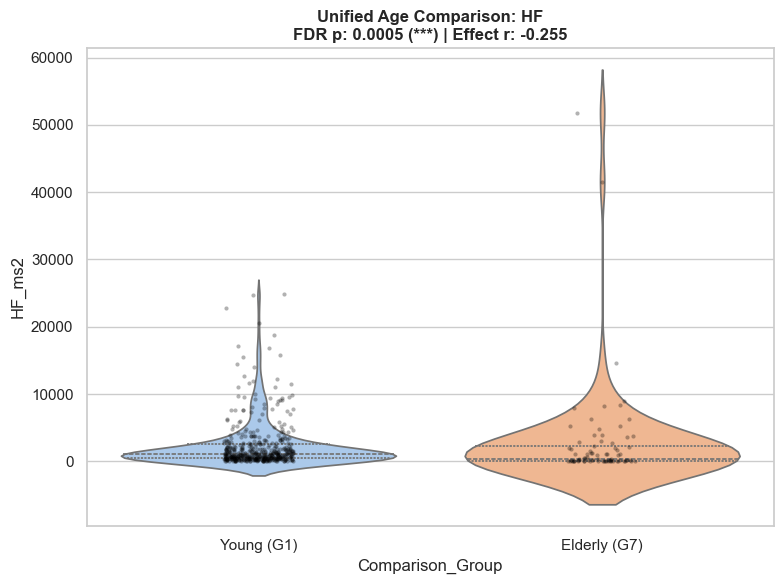

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


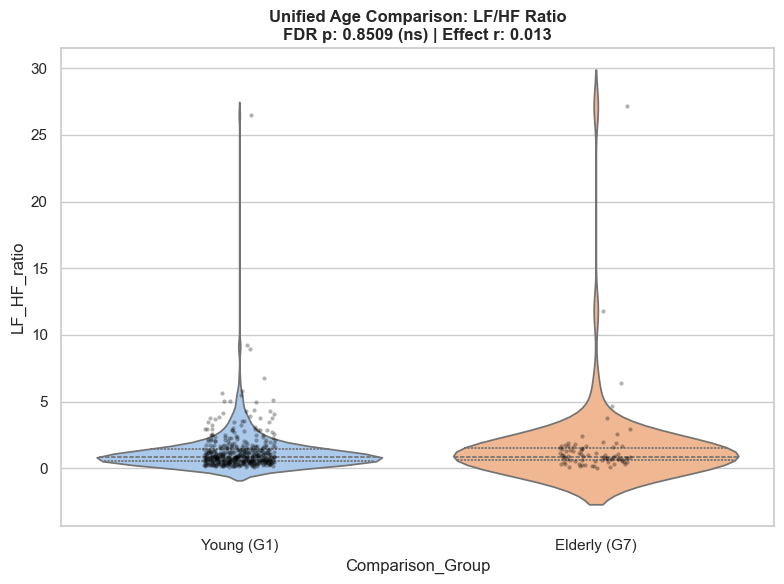

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


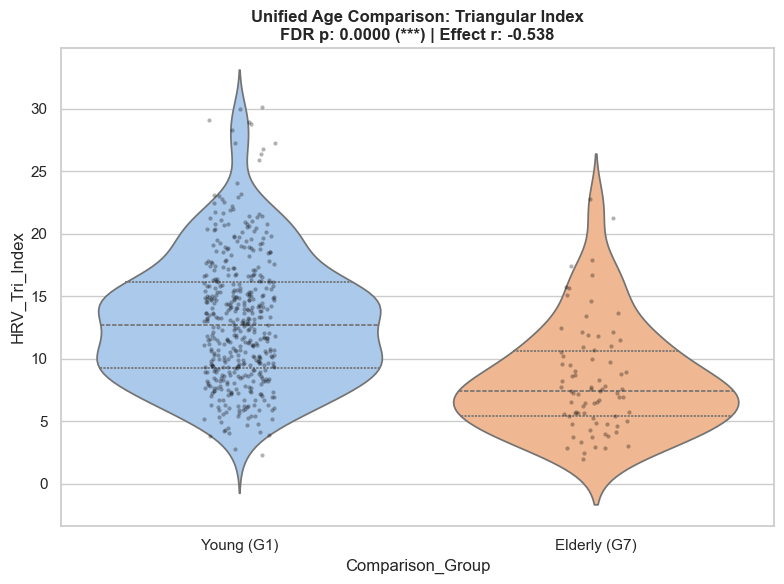

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


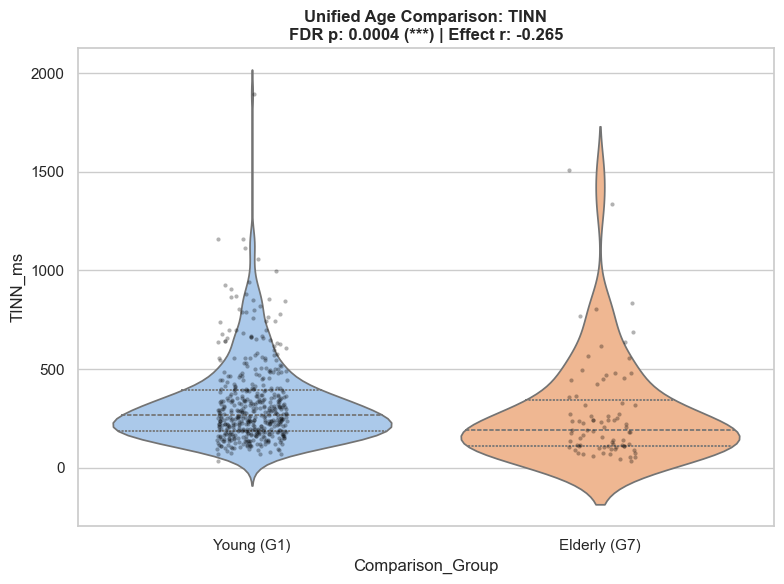

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


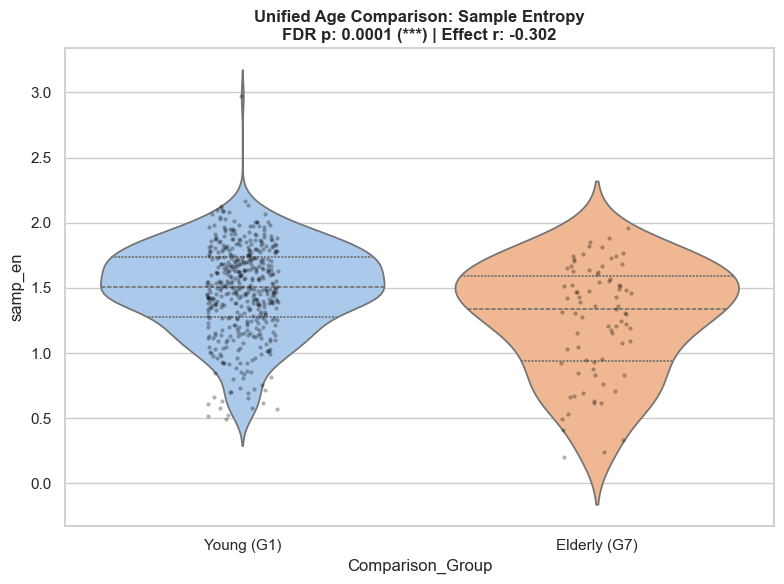

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


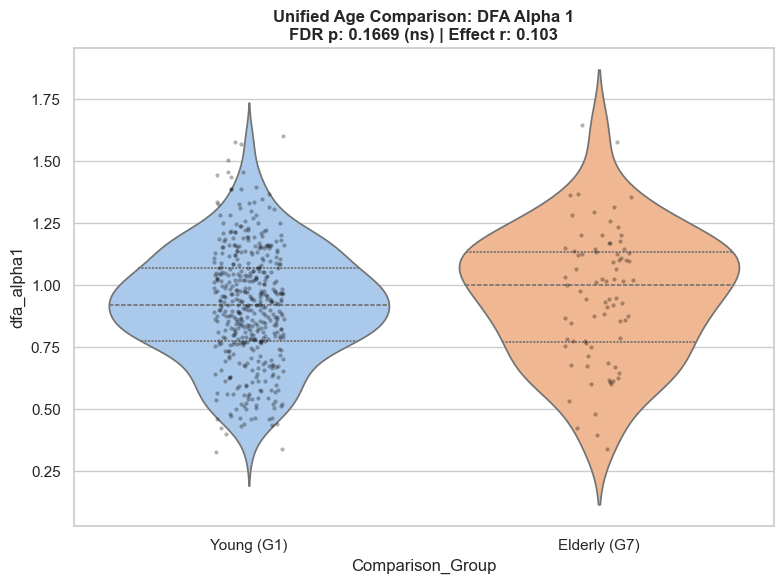

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


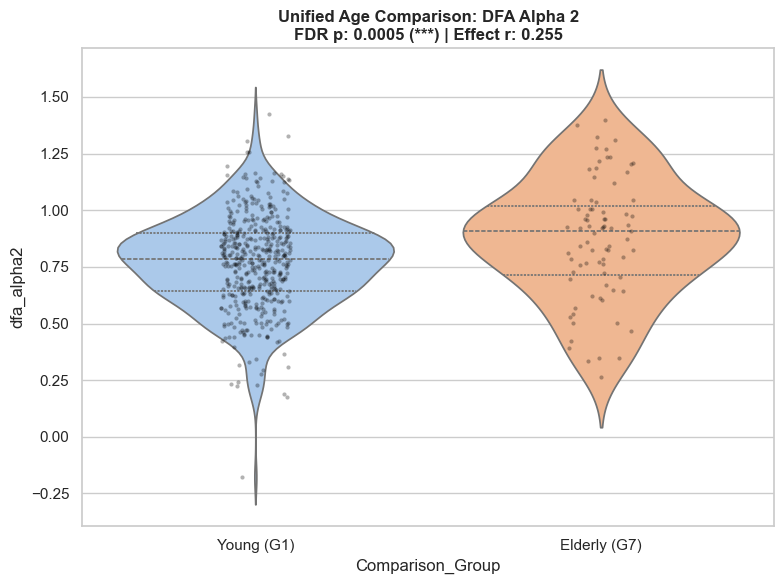

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


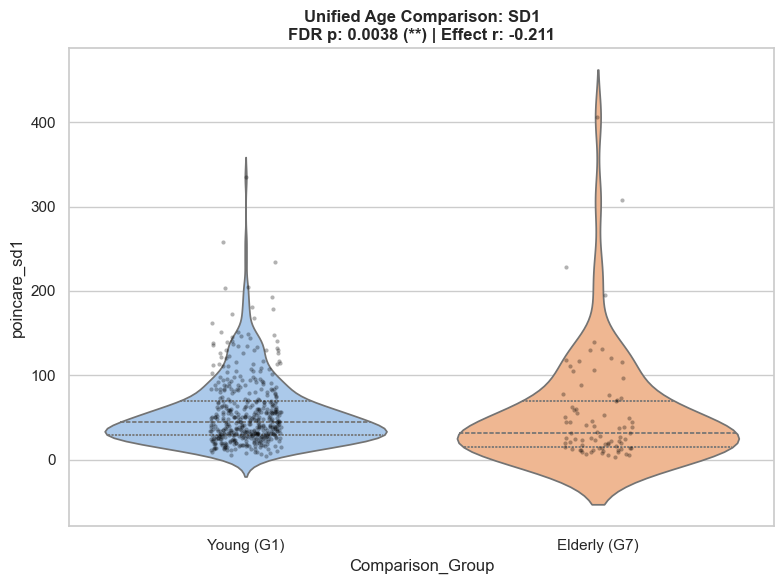

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


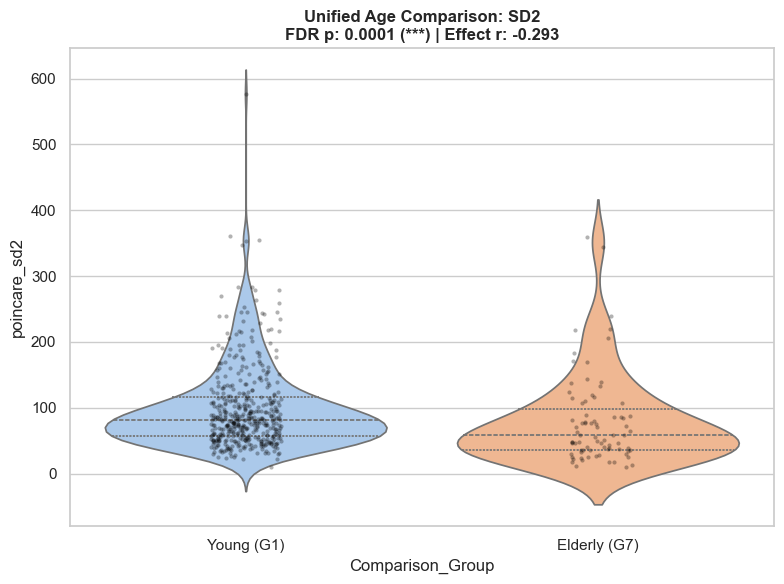

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2047070746.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


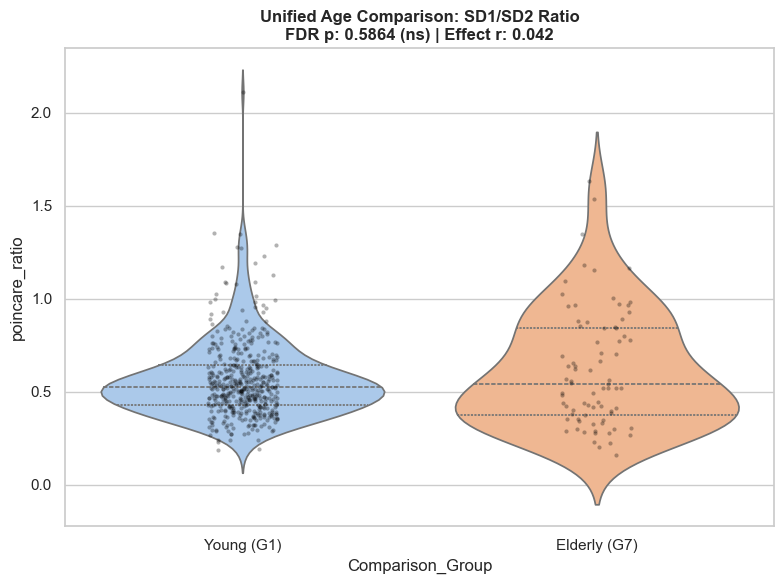

Unified Age Analysis (G1 vs G7) Complete.


In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manual FDR Correction Function 
def fdrcorrection_manual(pvals, alpha=0.05):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = pvals.argsort()
    pvals_sorted = pvals[order]
    ecdffactor = np.arange(1, n + 1) / float(n)
    reject = pvals_sorted <= (ecdffactor * alpha)
    if reject.any():
        reject_max = reject.nonzero()[0].max()
        reject[:reject_max + 1] = True
    pvals_corrected_raw = pvals_sorted / ecdffactor
    pvals_corrected = np.minimum.accumulate(pvals_corrected_raw[::-1])[::-1]
    pvals_corrected[pvals_corrected > 1] = 1
    out_reject = np.empty_like(reject)
    out_reject[order] = reject
    out_pvals_corrected = np.empty_like(pvals_corrected)
    out_pvals_corrected[order] = pvals_corrected
    return out_reject, out_pvals_corrected

# 2. Load and Prepare Data 
df_groups = pd.read_csv('analysis_groups.csv')
df_linear = pd.read_csv('final_hrv_linear_results.csv')
df_nonlinear = pd.read_csv('final_hrv_non_linear_results.csv')

# Sync IDs
for df in [df_groups, df_linear, df_nonlinear]:
    if 'Patient_ID' in df.columns:
        df.rename(columns={'Patient_ID': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.lstrip('0')

# Merge
df_merged = pd.merge(df_groups, df_linear, on='ID', how='inner')
df_merged = pd.merge(df_merged, df_nonlinear, on='ID', how='inner')

# 3. Define Polar Groups (1 vs 7) - Unified Genders 
def map_polar_groups(age_group):
    if age_group == 1: return 'Young (G1)'
    elif age_group == 7: return 'Elderly (G7)'
    return None

df_merged['Comparison_Group'] = df_merged['HRV_Age_Group'].apply(map_polar_groups)
# Drop rows not in G1 or G7
df_analysis = df_merged.dropna(subset=['Comparison_Group'])

# 4. Define Metrics & Run Unified Statistical Comparison 
metrics_map = {
    'meanNN_ms': 'MeanNN', 'sdNN_ms': 'SDNN', 'rmssd_ms': 'RMSSD',
    'pNN50_pct': 'pNN50', 'LF_ms2': 'LF', 'HF_ms2': 'HF',
    'LF_HF_ratio': 'LF/HF Ratio', 'HRV_Tri_Index': 'Triangular Index',
    'TINN_ms': 'TINN', 'samp_en': 'Sample Entropy',
    'dfa_alpha1': 'DFA Alpha 1', 'dfa_alpha2': 'DFA Alpha 2',
    'poincare_sd1': 'SD1', 'poincare_sd2': 'SD2', 'poincare_ratio': 'SD1/SD2 Ratio'
}

g_young = df_analysis[df_analysis['Comparison_Group'] == 'Young (G1)']
g_elderly = df_analysis[df_analysis['Comparison_Group'] == 'Elderly (G7)']

results = []
for col, clean_name in metrics_map.items():
    if col in df_analysis.columns:
        y_data, e_data = g_young[col].dropna(), g_elderly[col].dropna()
        if len(y_data) > 0 and len(e_data) > 0:
            u_stat, p_val = stats.mannwhitneyu(y_data, e_data, alternative='two-sided')
            # Effect Size r
            r = 1 - (2 * u_stat / (len(y_data) * len(e_data)))
            results.append({'Metric': clean_name, 'p_value': p_val, 'r': r, 'Col': col})

# Apply Unified FDR
df_stats = pd.DataFrame(results)
_, p_fdr = fdrcorrection_manual(df_stats['p_value'].values)
df_stats['p_FDR'] = p_fdr

# 5. VISUAL 1: Unified Autonomic Shift Summary
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
df_stats = df_stats.sort_values('r', ascending=True)

# Map colors (Blue = Higher in Young, Red = Higher in Elderly)
colors = ['#4C72B0' if x < 0 else '#C44E52' for x in df_stats['r']]

ax = sns.barplot(
    data=df_stats, 
    x='r', 
    y='Metric', 
    hue='Metric', 
    palette=colors, 
    legend=False
)

# Add Significance Stars
for i, (p, r) in enumerate(zip(df_stats['p_FDR'], df_stats['r'])):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    offset = 0.02 if r >= 0 else -0.02
    ax.text(r + offset, i, stars, va='center', ha='left' if r >= 0 else 'right', fontweight='bold', fontsize=12)

plt.title('Autonomic Aging: Unified Comparison\nYoung (G1) vs. Elderly (G7)', fontsize=14, fontweight='bold')
plt.xlabel('Effect Size (r)\n[Negative = Higher in Youth | Positive = Higher in Elderly]')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

# 6. VISUAL 2: Unified Violin Plots
for col, clean_name in metrics_map.items():
    if col in df_analysis.columns:
        fdr_p = df_stats.loc[df_stats['Metric'] == clean_name, 'p_FDR'].values[0]
        r_val = df_stats.loc[df_stats['Metric'] == clean_name, 'r'].values[0]
        stars = "***" if fdr_p < 0.001 else "**" if fdr_p < 0.01 else "*" if fdr_p < 0.05 else "ns"
        
        plt.figure(figsize=(8, 6))
        sns.violinplot(
            data=df_analysis, 
            x='Comparison_Group', 
            y=col, 
            order=['Young (G1)', 'Elderly (G7)'], 
            inner='quartile', 
            palette="pastel"
        )
        sns.stripplot(
            data=df_analysis, 
            x='Comparison_Group', 
            y=col, 
            order=['Young (G1)', 'Elderly (G7)'], 
            color="black", alpha=0.3, jitter=True, size=3
        )
        plt.title(f"Unified Age Comparison: {clean_name}\nFDR p: {fdr_p:.4f} ({stars}) | Effect r: {r_val:.3f}", fontweight='bold')
        plt.tight_layout()
        plt.show()

print("Unified Age Analysis (G1 vs G7) Complete.")

Midlife transition: diff between (30-39 years) and (40-49 years) - @article{knight2020parasympathetic,
  author  = {Knight, E. L. and Giuliano, R. J. and Shank, S. W. and Clarke, M. M. and Almeida, D. M.},
  title   = {Parasympathetic and sympathetic nervous systems interactively predict change in cognitive functioning in midlife adults},
  journal = {Psychophysiology},
  volume  = {57},
  number  = {10},
  pages   = {e13622},
  year    = {2020},
  doi     = {10.1111/psyp.13622},
  pmid    = {32598489},
  pmcid   = {PMC7722158}
}

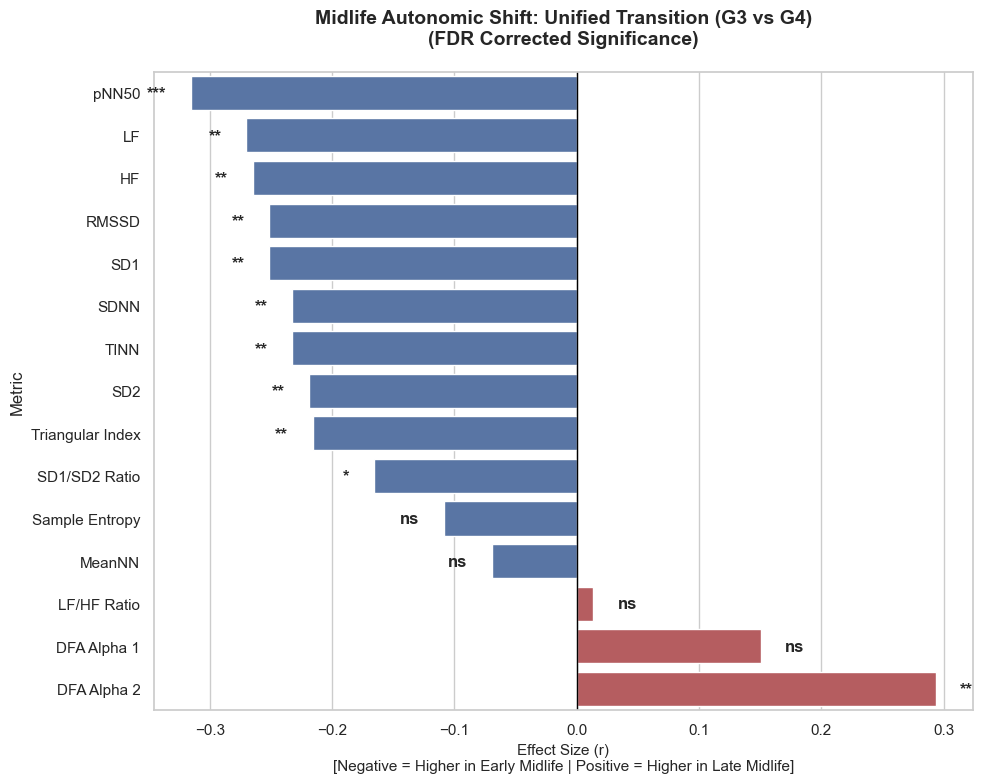

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


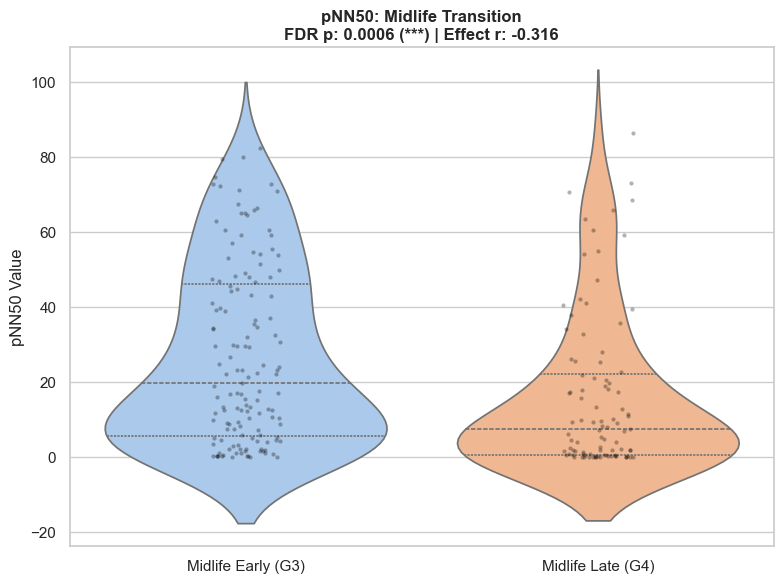

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


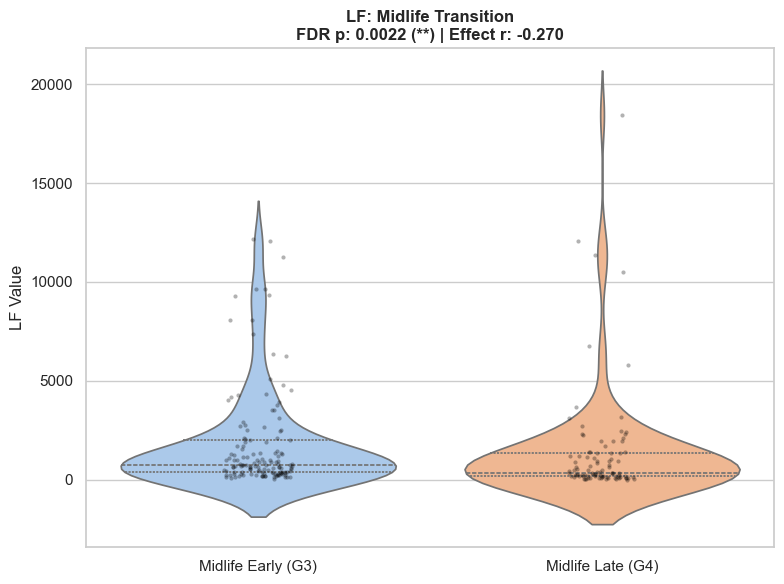

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


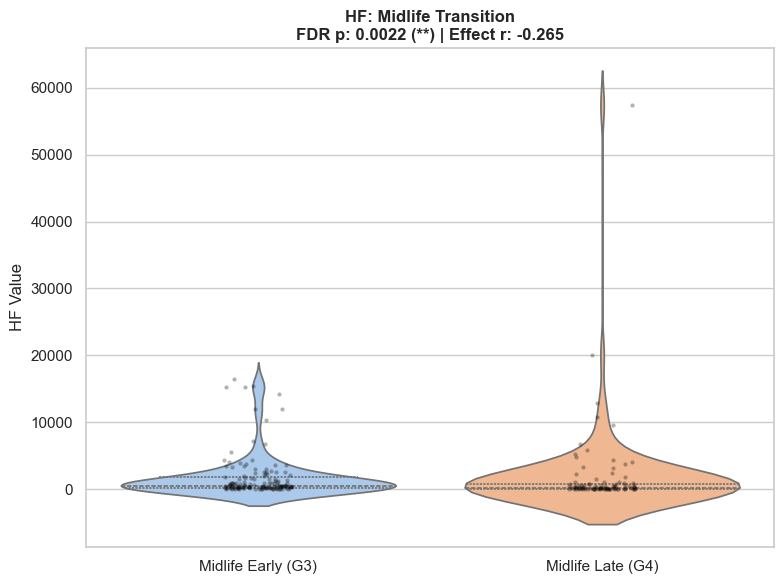

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


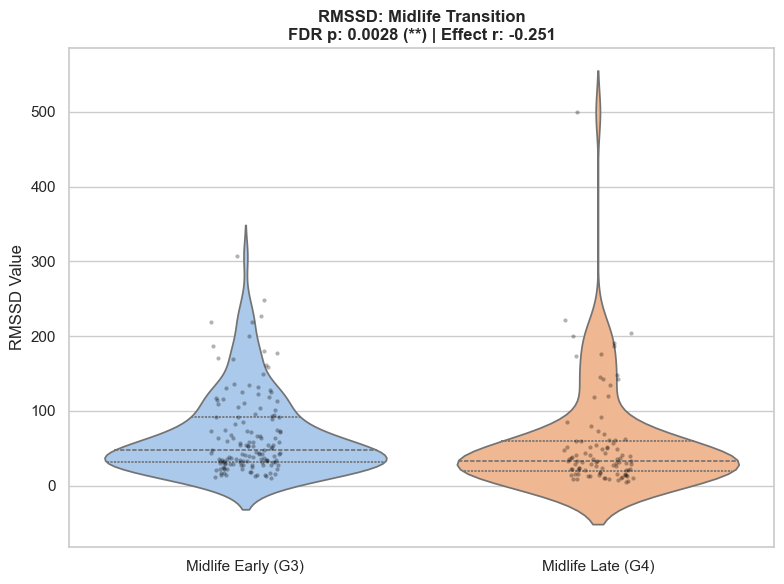

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


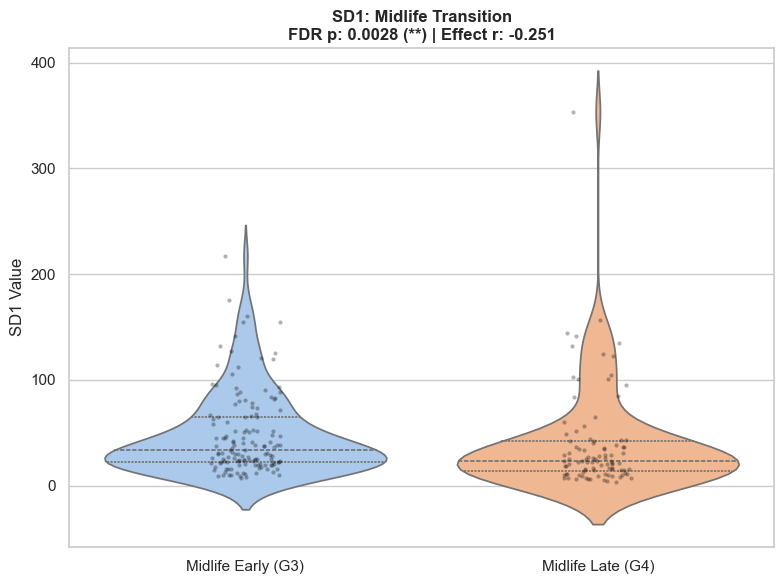

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


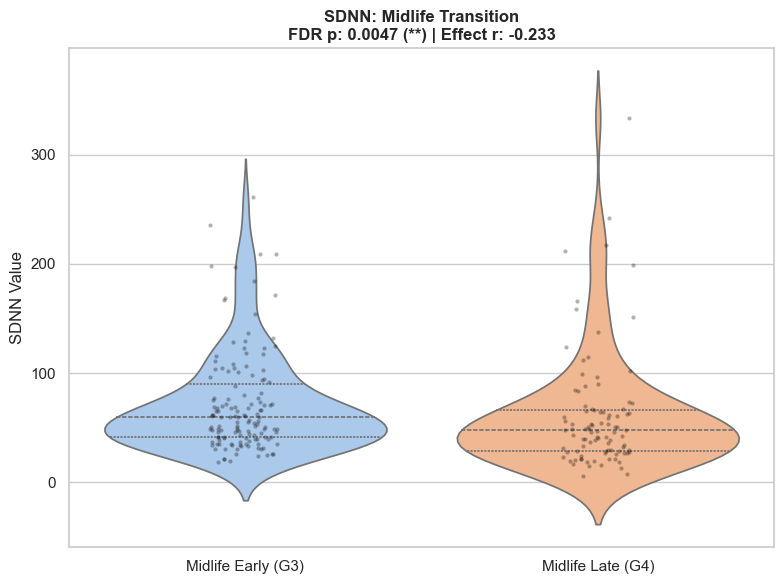

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


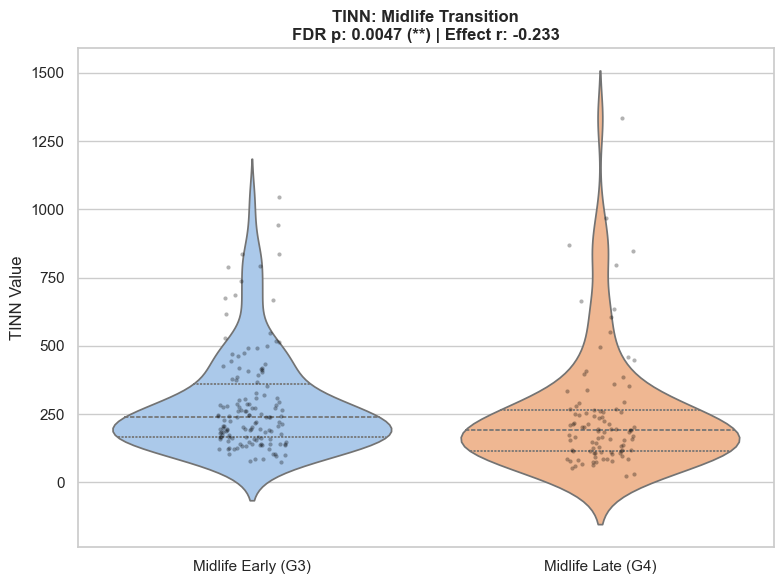

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


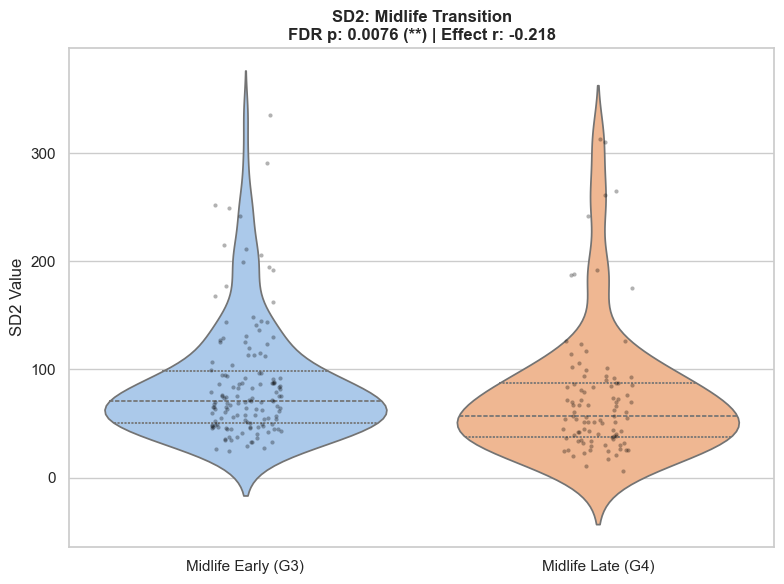

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


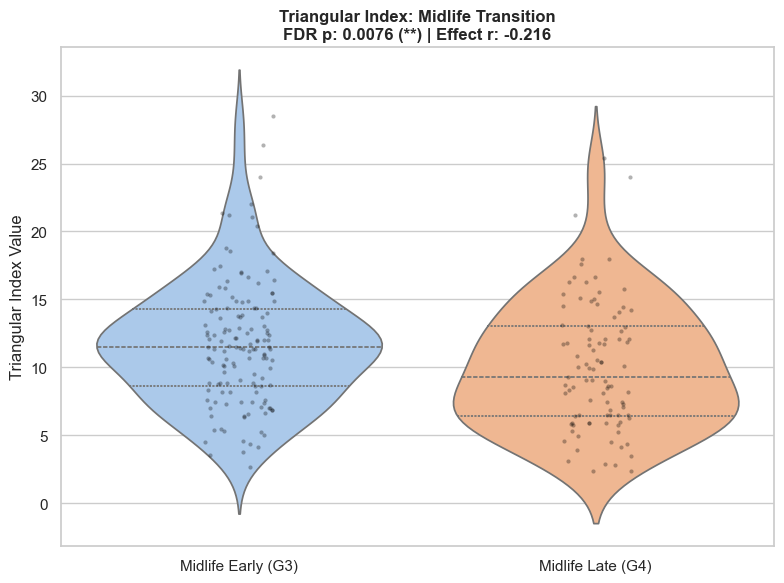

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


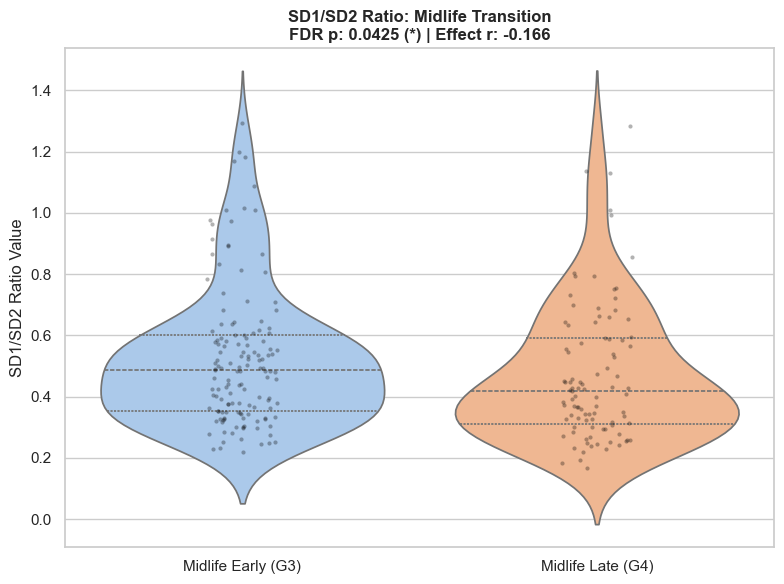

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


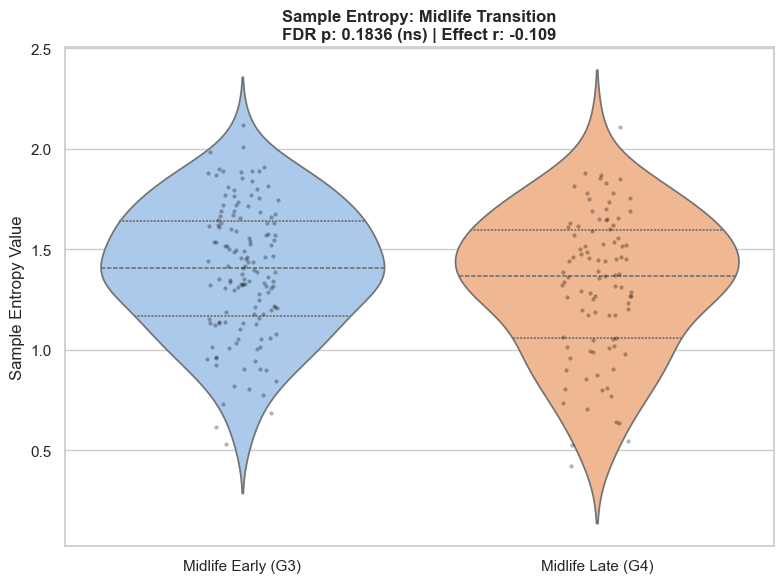

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


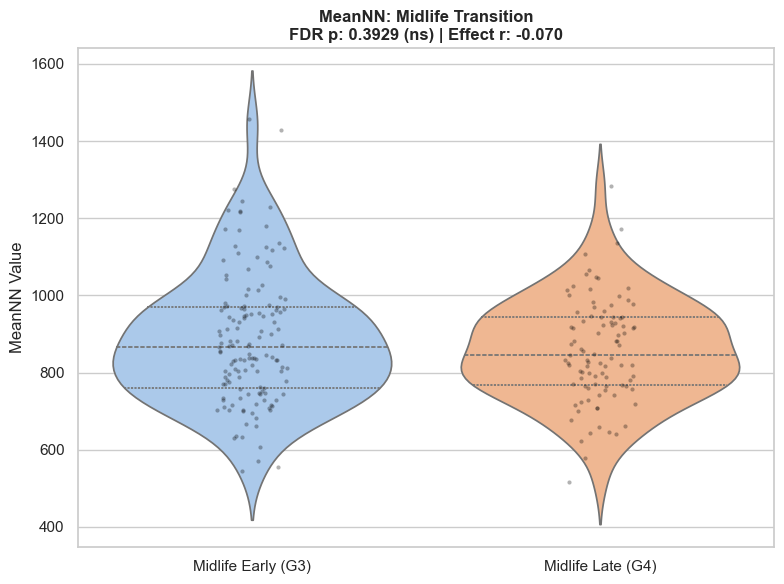

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


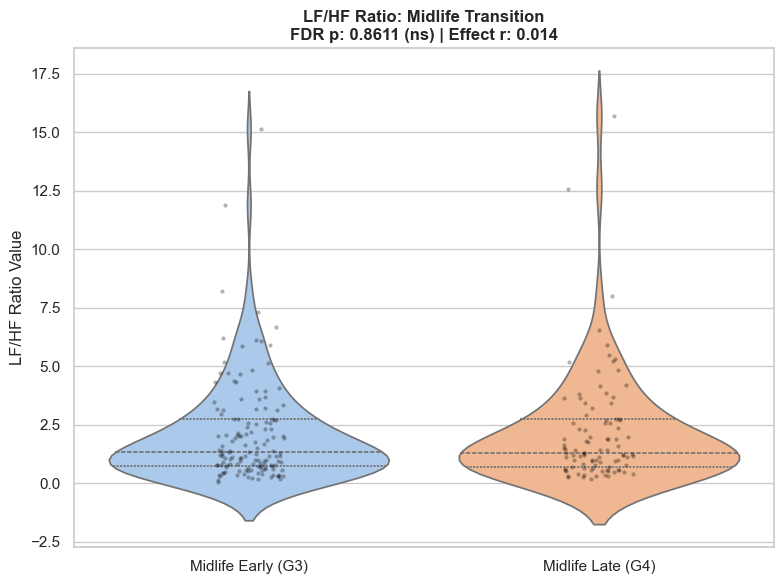

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


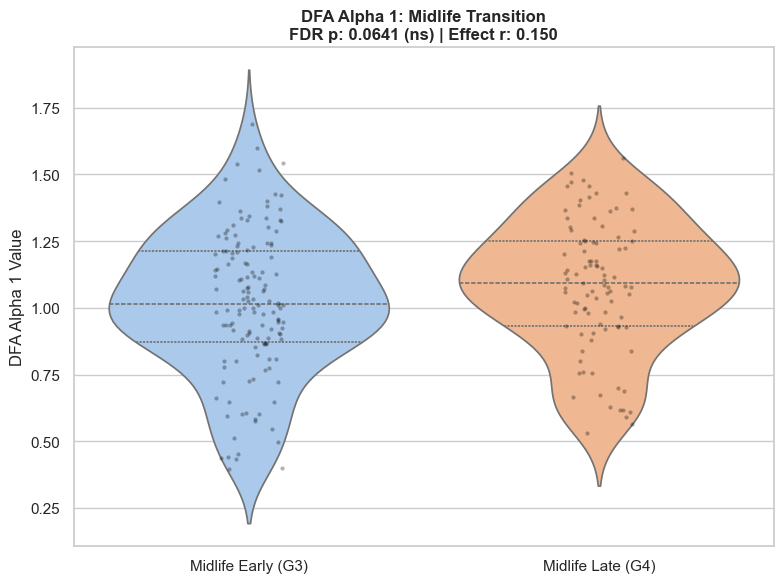

C:\Users\34673\AppData\Local\Temp\ipykernel_26776\2762936664.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


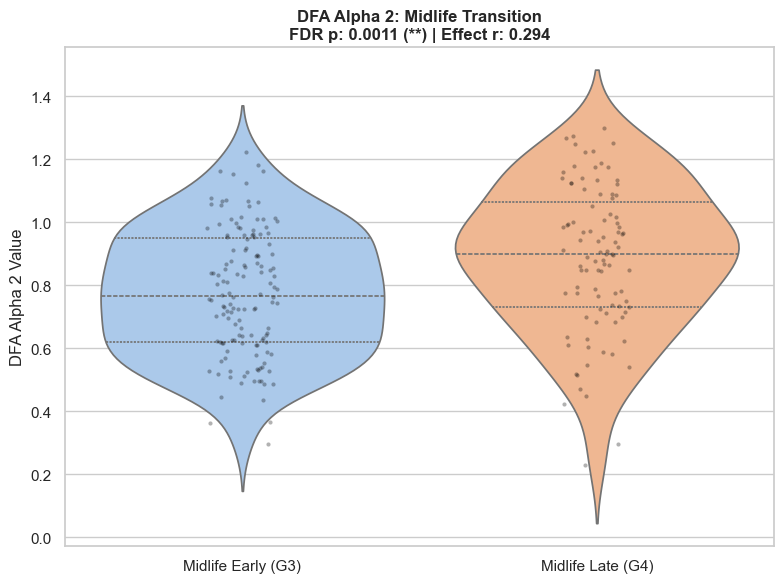

Unified Midlife Analysis (G3 vs G4) Successfully Completed.


In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manual FDR Correction Function 
def fdrcorrection_manual(pvals, alpha=0.05):
    """Performs Benjamini-Hochberg FDR correction."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = pvals.argsort()
    pvals_sorted = pvals[order]
    ecdffactor = np.arange(1, n + 1) / float(n)
    reject = pvals_sorted <= (ecdffactor * alpha)
    if reject.any():
        reject_max = reject.nonzero()[0].max()
        reject[:reject_max + 1] = True
    pvals_corrected_raw = pvals_sorted / ecdffactor
    pvals_corrected = np.minimum.accumulate(pvals_corrected_raw[::-1])[::-1]
    pvals_corrected[pvals_corrected > 1] = 1
    out_reject = np.empty_like(reject)
    out_reject[order] = reject
    out_pvals_corrected = np.empty_like(pvals_corrected)
    out_pvals_corrected[order] = pvals_corrected
    return out_reject, out_pvals_corrected

# 2. Load and Prepare Data
df_groups = pd.read_csv('analysis_groups.csv')
df_linear = pd.read_csv('final_hrv_linear_results.csv')
df_nonlinear = pd.read_csv('final_hrv_non_linear_results.csv')

# ID Standardization and Renaming for Merging
for df in [df_groups, df_linear, df_nonlinear]:
    if 'Patient_ID' in df.columns:
        df.rename(columns={'Patient_ID': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.lstrip('0')

# Inner Join to create a master dataset
df_merged = pd.merge(df_groups, df_linear, on='ID', how='inner')
df_merged = pd.merge(df_merged, df_nonlinear, on='ID', how='inner')

# 3. Define Midlife Comparison Groups (Unified Genders) 
def map_midlife_groups(age_group):
    if age_group == 3: return 'Midlife Early (G3)'
    elif age_group == 4: return 'Midlife Late (G4)'
    return None

df_merged['Comparison_Group'] = df_merged['HRV_Age_Group'].apply(map_midlife_groups)
df_analysis = df_merged.dropna(subset=['Comparison_Group'])

# 4. Define Metrics & Run Unified Statistical Comparison 
metrics_map = {
    'meanNN_ms': 'MeanNN', 'sdNN_ms': 'SDNN', 'rmssd_ms': 'RMSSD',
    'pNN50_pct': 'pNN50', 'LF_ms2': 'LF', 'HF_ms2': 'HF',
    'LF_HF_ratio': 'LF/HF Ratio', 'HRV_Tri_Index': 'Triangular Index',
    'TINN_ms': 'TINN', 'samp_en': 'Sample Entropy',
    'dfa_alpha1': 'DFA Alpha 1', 'dfa_alpha2': 'DFA Alpha 2',
    'poincare_sd1': 'SD1', 'poincare_sd2': 'SD2', 'poincare_ratio': 'SD1/SD2 Ratio'
}

g_early = df_analysis[df_analysis['Comparison_Group'] == 'Midlife Early (G3)']
g_late = df_analysis[df_analysis['Comparison_Group'] == 'Midlife Late (G4)']

results_list = []
for col, clean_name in metrics_map.items():
    if col in df_analysis.columns:
        d_early = g_early[col].dropna()
        d_late = g_late[col].dropna()
        
        if len(d_early) > 0 and len(d_late) > 0:
            u_stat, p_val = stats.mannwhitneyu(d_early, d_late, alternative='two-sided')
            # Effect Size r: Rank-Biserial Correlation
            r = 1 - (2 * u_stat / (len(d_early) * len(d_late)))
            results_list.append({'Metric': clean_name, 'p_value': p_val, 'r': r, 'Col': col})

# Create stats dataframe and apply FDR
df_stats = pd.DataFrame(results_list)
_, p_fdr = fdrcorrection_manual(df_stats['p_value'].values)
df_stats['p_FDR'] = p_fdr

# 5. VISUAL 1: Midlife Autonomic Shift Summary Map
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
df_stats = df_stats.sort_values('r', ascending=True)

# Color logic: Blue for Early > Late, Red for Late > Early
colors = ['#4C72B0' if x < 0 else '#C44E52' for x in df_stats['r']]

ax = sns.barplot(
    data=df_stats, 
    x='r', 
    y='Metric', 
    hue='Metric', 
    palette=colors
)
# Safely remove legend if it appears
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Adding Significance Stars
for i, (p, r) in enumerate(zip(df_stats['p_FDR'], df_stats['r'])):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    offset = 0.02 if r >= 0 else -0.02
    ax.text(r + offset, i, stars, va='center', ha='left' if r >= 0 else 'right', 
            fontweight='bold', fontsize=12)

plt.title('Midlife Autonomic Shift: Unified Transition (G3 vs G4)\n(FDR Corrected Significance)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Effect Size (r)\n[Negative = Higher in Early Midlife | Positive = Higher in Late Midlife]', fontsize=11)
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

# 6. VISUAL 2: Individual Unified Violin Plots
for _, row in df_stats.iterrows():
    col = row['Col']
    clean_name = row['Metric']
    fdr_p = row['p_FDR']
    r_val = row['r']
    
    plt.figure(figsize=(8, 6))
    # Corrected order to ensure consistent comparison
    sns.violinplot(
        data=df_analysis, 
        x='Comparison_Group', 
        y=col, 
        order=['Midlife Early (G3)', 'Midlife Late (G4)'], 
        inner='quartile', 
        palette="pastel"
    )
    sns.stripplot(
        data=df_analysis, 
        x='Comparison_Group', 
        y=col, 
        order=['Midlife Early (G3)', 'Midlife Late (G4)'], 
        color="black", alpha=0.3, jitter=True, size=3
    )
    
    # Dynamic star calculation for title
    stars = "***" if fdr_p < 0.001 else "**" if fdr_p < 0.01 else "*" if fdr_p < 0.05 else "ns"
    plt.title(f"{clean_name}: Midlife Transition\nFDR p: {fdr_p:.4f} ({stars}) | Effect r: {r_val:.3f}", 
              fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel(f"{clean_name} Value")
    plt.tight_layout()
    plt.show()

print("Unified Midlife Analysis (G3 vs G4) Successfully Completed.")

Gender-specific aging patterns

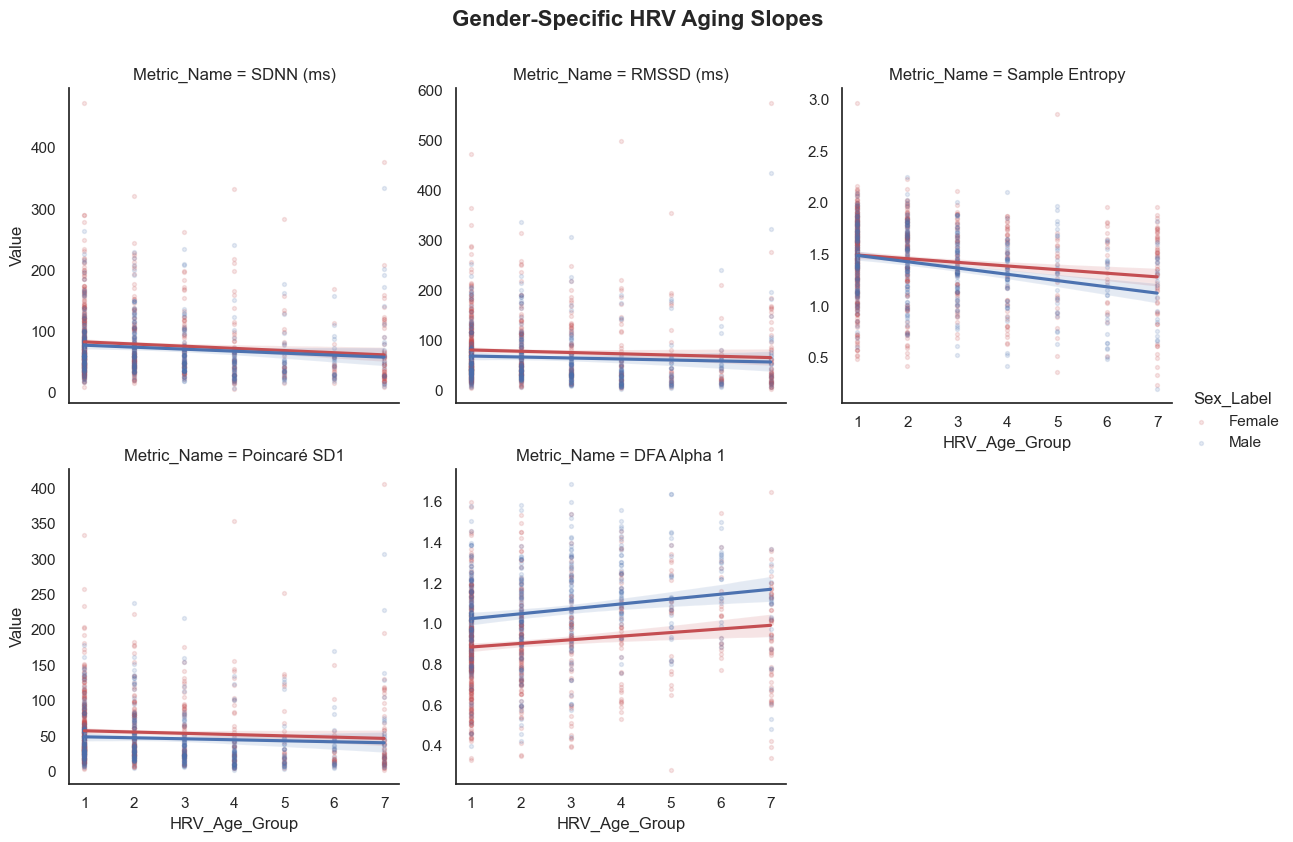

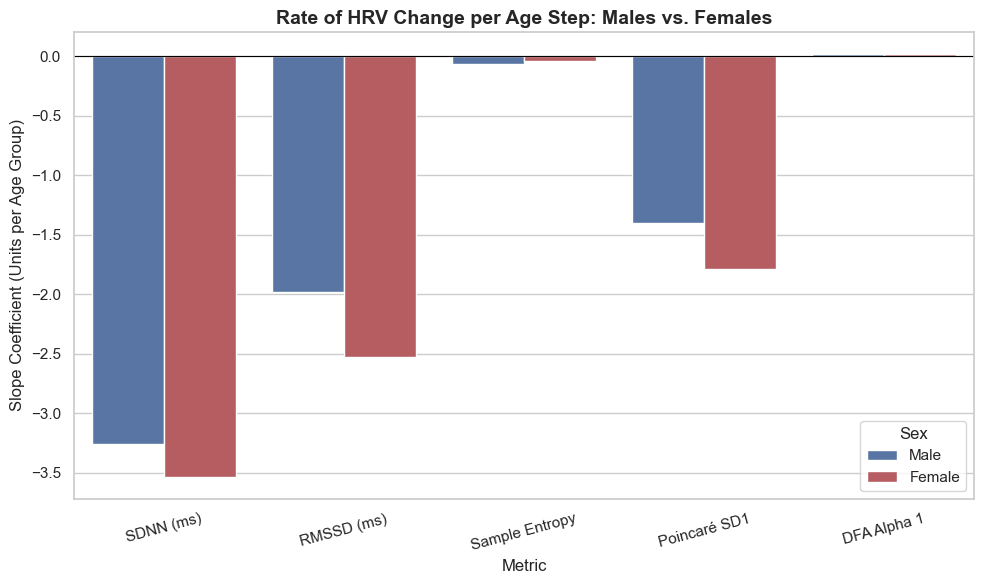

      Sex          Metric     Slope       p_value
0    Male       SDNN (ms) -3.263527  1.159605e-02
1    Male      RMSSD (ms) -1.979321  2.180911e-01
2    Male  Sample Entropy -0.060819  1.439930e-10
3    Male    Poincaré SD1 -1.399603  2.180849e-01
4    Male     DFA Alpha 1  0.024070  2.539227e-04
5  Female       SDNN (ms) -3.540823  1.728968e-03
6  Female      RMSSD (ms) -2.527407  5.826021e-02
7  Female  Sample Entropy -0.035227  6.762052e-06
8  Female    Poincaré SD1 -1.787168  5.825335e-02
9  Female     DFA Alpha 1  0.017794  2.397107e-04


In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df_groups = pd.read_csv('analysis_groups.csv')
df_linear = pd.read_csv('final_hrv_linear_results.csv')
df_nonlinear = pd.read_csv('final_hrv_non_linear_results.csv')

# ID Standardization and Merge
for df in [df_groups, df_linear, df_nonlinear]:
    if 'Patient_ID' in df.columns:
        df.rename(columns={'Patient_ID': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.lstrip('0')

df_merged = pd.merge(df_groups, df_linear, on='ID', how='inner')
df_merged = pd.merge(df_merged, df_nonlinear, on='ID', how='inner')

# 2. Representative Metrics for Slope Analysis
metrics_map = {
    'sdNN_ms': 'SDNN (ms)',
    'rmssd_ms': 'RMSSD (ms)',
    'samp_en': 'Sample Entropy',
    'poincare_sd1': 'Poincaré SD1',
    'dfa_alpha1': 'DFA Alpha 1'
}

# 3. Calculate Slopes for each gender using Linear Regression
slope_results = []
for sex in ['Male', 'Female']:
    df_sex = df_merged[df_merged['Sex_Label'] == sex]
    for metric_col, metric_name in metrics_map.items():
        data = df_sex[['HRV_Age_Group', metric_col]].dropna()
        if len(data) > 5:
            # linregress returns (slope, intercept, r_value, p_value, std_err)
            slope, _, _, p_val, _ = stats.linregress(data['HRV_Age_Group'], data[metric_col])
            slope_results.append({
                'Sex': sex, 'Metric': metric_name, 'Slope': slope, 'p_value': p_val, 'Col': metric_col
            })

df_slopes = pd.DataFrame(slope_results)

# 4. VISUAL 1: Comparative Regression Map 
df_long = df_merged.melt(id_vars=['ID', 'Sex_Label', 'HRV_Age_Group'], 
                         value_vars=list(metrics_map.keys()),
                         var_name='Col', value_name='Value')
df_long['Metric_Name'] = df_long['Col'].map(metrics_map)

sns.set_theme(style="white")
g = sns.lmplot(data=df_long, x='HRV_Age_Group', y='Value', hue='Sex_Label', 
               col='Metric_Name', col_wrap=3, height=4, aspect=1,
               scatter_kws={'alpha': 0.15, 's': 8}, 
               palette={'Male': '#4C72B0', 'Female': '#C44E52'},
               facet_kws={'sharey': False})

g.fig.suptitle("Gender-Specific HRV Aging Slopes", y=1.05, fontsize=16, fontweight='bold')
plt.show()

# 5. VISUAL 2: Slope Comparison (Rate of Change)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_slopes, x='Metric', y='Slope', hue='Sex', 
            palette={'Male': '#4C72B0', 'Female': '#C44E52'})

plt.title("Rate of HRV Change per Age Step: Males vs. Females", fontsize=14, fontweight='bold')
plt.ylabel("Slope Coefficient (Units per Age Group)")
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(df_slopes[['Sex', 'Metric', 'Slope', 'p_value']])